# Self-training dynamics

This notebook visualizes the feedback loop between classifier quality, confidence selection, and selected pseudo-label precision under the current finite and effective-dynamics implementations.

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit, expit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    class_conditional_update_observables,
    trajectory_diagnostics,
    plot_macroscopic_evolution,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler

from src.performance import bayes_parameters, population_error


The primary quantity of interest is the selected pseudo-label accuracy
$$
A_{\rm PL}^t= \mathbb{P}(\hat Y^t=Y \mid \Delta=0,S_\kappa(r^t)=1)=\frac{\mathbb P(\Delta=0,S_\kappa(r^t)=1,\hat Y^t=Y)}
{\mathbb P(\Delta=0,S_\kappa(r^t)=1)}.
$$


## $p = 0.2$, $\kappa = \mathrm{logit}(0.5)$

In [18]:
SEED = 2026
T, D, DELTA = 200, 5_000, 4.0
SIGMA, RHO, P, S_MU = 1.0, 0.1, 0.2, 1.0
K_W, K_G = 7_000, 8_500

cfg = make_algorithm_config(
    T=T, eta=0.5, penalty=0.1, pi=2.0, kappa=logit(0.5), include_bias=True
)
run = run_experiment(
    name="representative self-training dynamics", d=D, delta=DELTA, n_test=5_000,
    label_prior=P, rho=RHO, sigma=SIGMA, signal_std=S_MU,
    algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
)
finite_state, se_state = finite_state_observables(run), state_evolution_state_observables(run)
finite_update, se_update = finite_update_observables(run), state_evolution_update_observables(run)

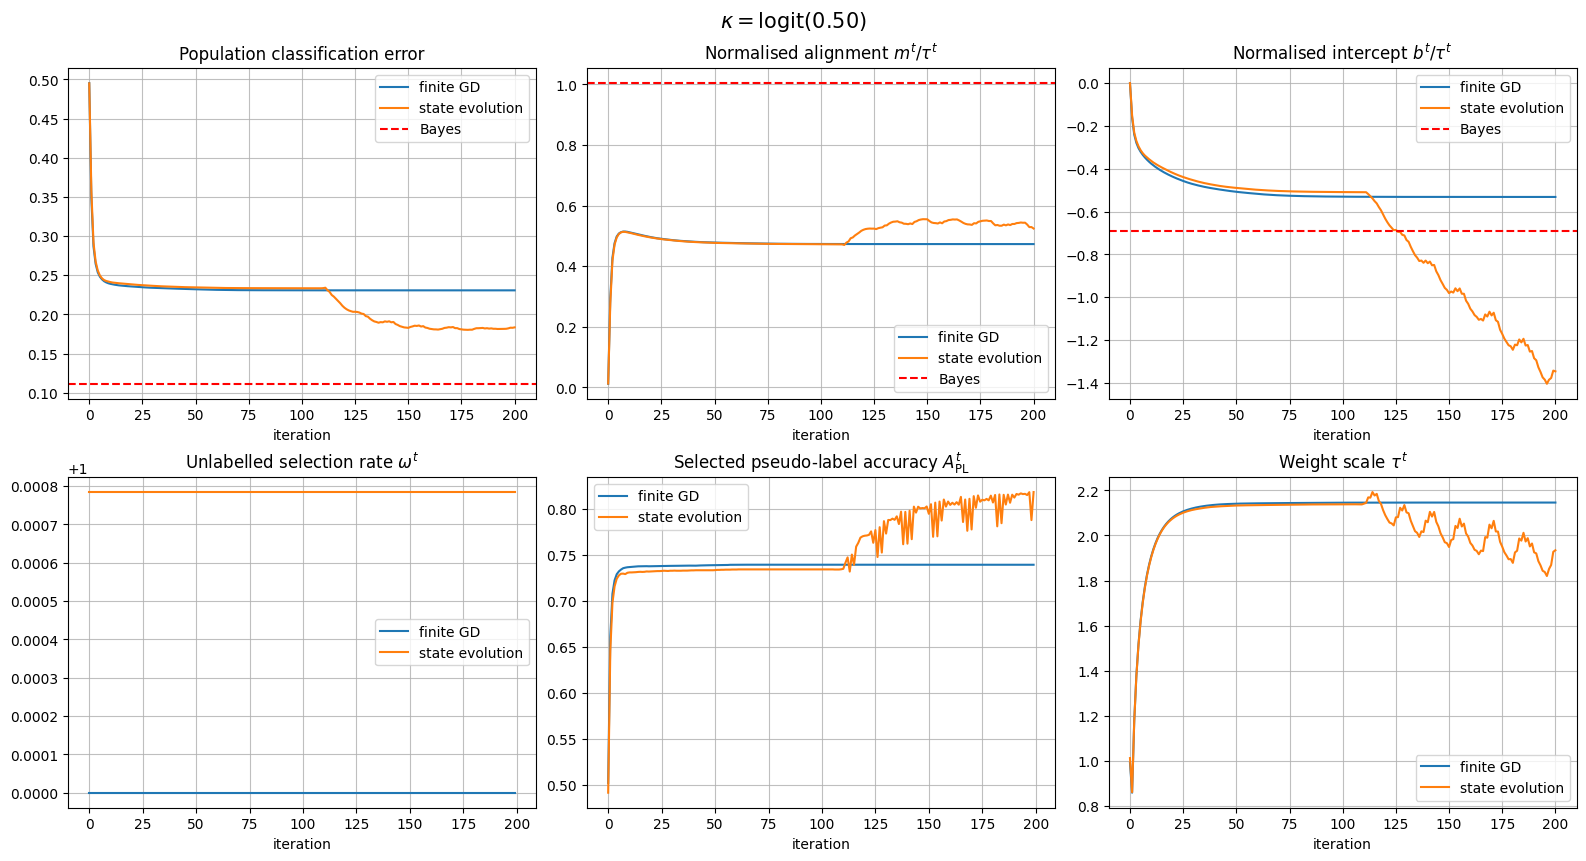

(<Figure size 1575x850 with 6 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Unlabelled selection rate $\\omega^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Selected pseudo-label accuracy $A_{\\rm PL}^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [19]:
plot_macroscopic_evolution(
    run,
    quantities=("error", "normalized_alignment", "normalized_bias", "omega", "accuracy", "tau"),
    sources=("finite", "state_evolution"),
    include_bayes=True,
    title=rf"$\kappa = \mathrm{{logit}}({expit(cfg.margin_threshold):.2f})$",
    nrows=2, ncols=3
)

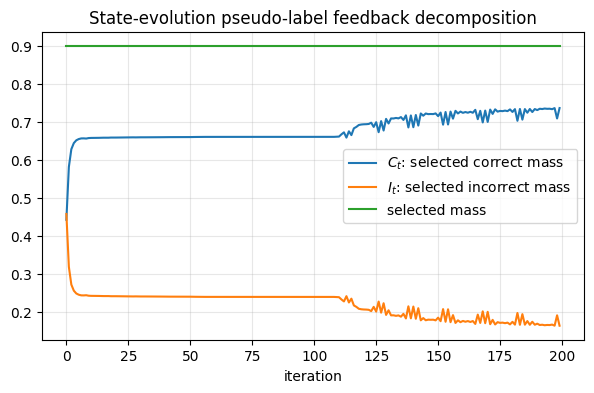

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(se_update["correct_mass"], label=r"$C_t$: selected correct mass")
ax.plot(se_update["incorrect_mass"], label=r"$I_t$: selected incorrect mass")
ax.plot(se_update["omega"] * (1 - run.data_cfg.supervision_ratio), label=r"selected mass")
ax.set(xlabel="iteration", title="State-evolution pseudo-label feedback decomposition")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## $p = 0.2$, $\kappa = \mathrm{logit}(0.6)$

In [21]:
SEED = 2026
T, D, DELTA = 200, 5_000, 4.0
SIGMA, RHO, P, S_MU = 1.0, 0.1, 0.2, 1.0
K_W, K_G = 7_000, 8_500

cfg = make_algorithm_config(
    T=T, eta=0.5, penalty=0.1, pi=2.0, kappa=logit(0.6), include_bias=True
)
run = run_experiment(
    name="representative self-training dynamics", d=D, delta=DELTA, n_test=5_000,
    label_prior=P, rho=RHO, sigma=SIGMA, signal_std=S_MU,
    algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
)
finite_state, se_state = finite_state_observables(run), state_evolution_state_observables(run)
finite_update, se_update = finite_update_observables(run), state_evolution_update_observables(run)

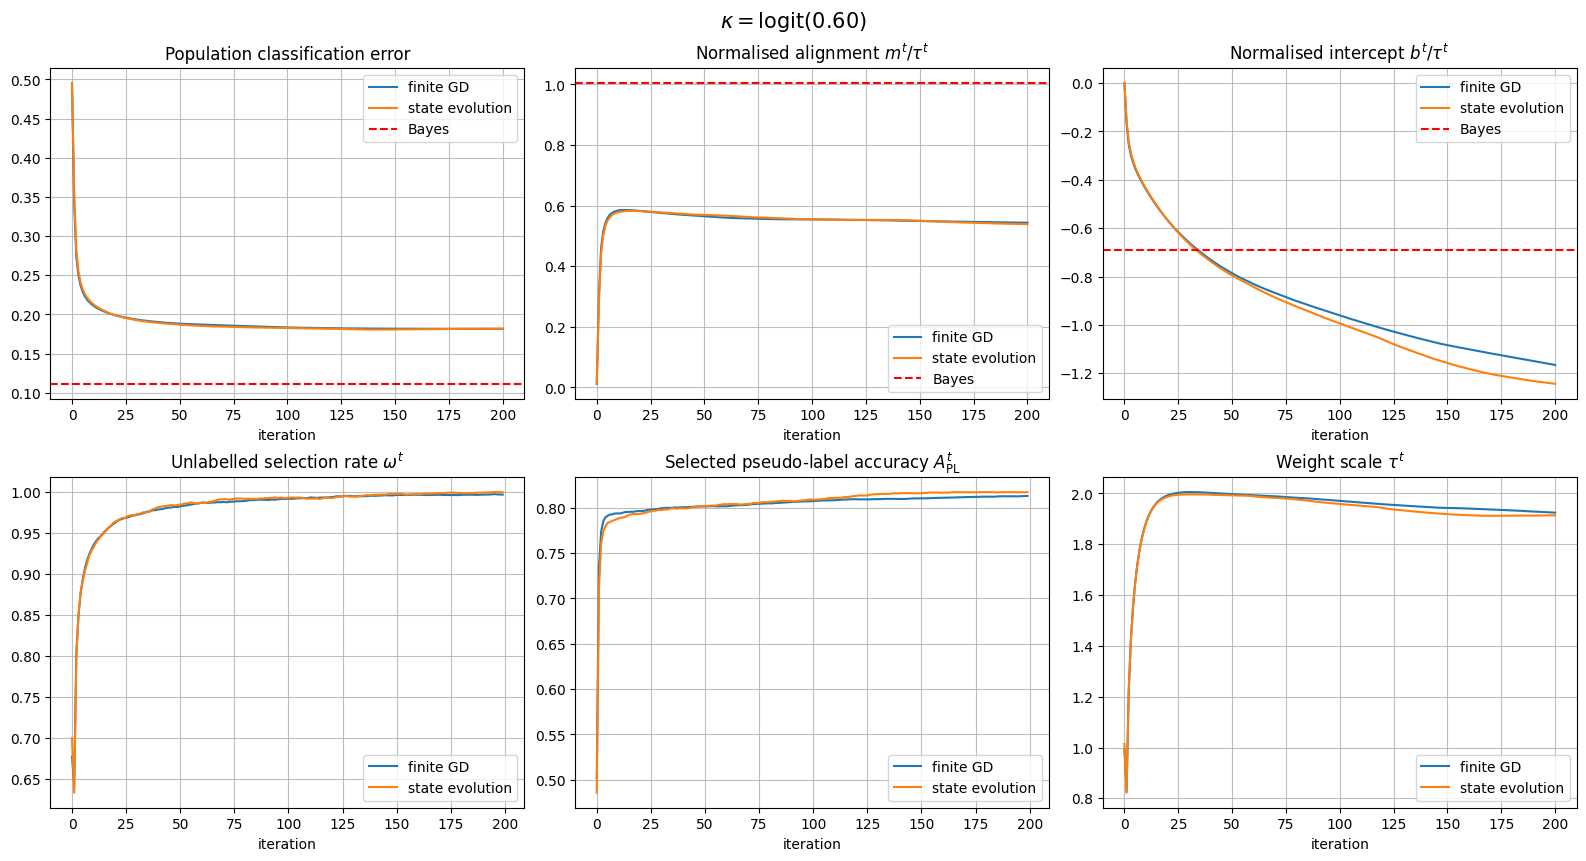

(<Figure size 1575x850 with 6 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Unlabelled selection rate $\\omega^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Selected pseudo-label accuracy $A_{\\rm PL}^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [22]:
plot_macroscopic_evolution(
    run,
    quantities=("error", "normalized_alignment", "normalized_bias", "omega", "accuracy", "tau"),
    sources=("finite", "state_evolution"),
    include_bayes=True,
    title=rf"$\kappa = \mathrm{{logit}}({expit(cfg.margin_threshold):.2f})$",
    nrows=2, ncols=3
)

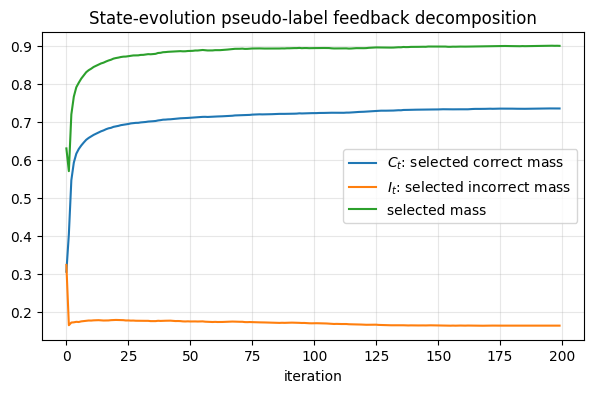

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(se_update["correct_mass"], label=r"$C_t$: selected correct mass")
ax.plot(se_update["incorrect_mass"], label=r"$I_t$: selected incorrect mass")
ax.plot(se_update["omega"] * (1 - run.data_cfg.supervision_ratio), label=r"selected mass")
ax.set(xlabel="iteration", title="State-evolution pseudo-label feedback decomposition")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## $p = 0.2$, $\kappa = \mathrm{logit}(0.8)$

In [24]:
SEED = 2026
T, D, DELTA = 200, 5_000, 4.0
SIGMA, RHO, P, S_MU = 1.0, 0.1, 0.2, 1.0
K_W, K_G = 7_000, 8_500

cfg = make_algorithm_config(
    T=T, eta=0.5, penalty=0.1, pi=2.0, kappa=logit(0.8), include_bias=True
)
run = run_experiment(
    name="representative self-training dynamics", d=D, delta=DELTA, n_test=5_000,
    label_prior=P, rho=RHO, sigma=SIGMA, signal_std=S_MU,
    algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
)
finite_state, se_state = finite_state_observables(run), state_evolution_state_observables(run)
finite_update, se_update = finite_update_observables(run), state_evolution_update_observables(run)

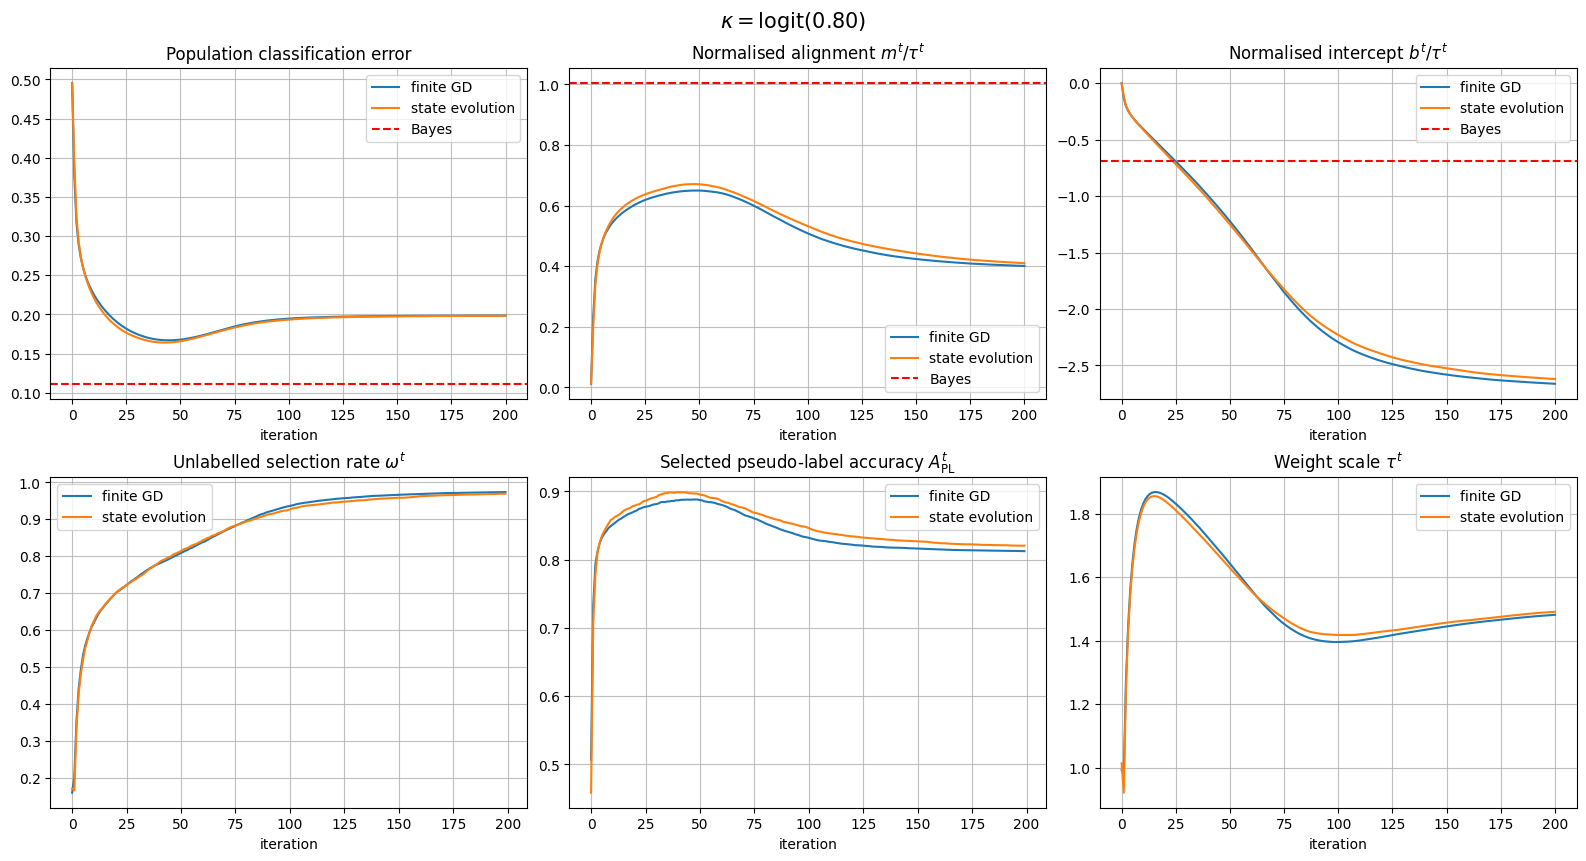

(<Figure size 1575x850 with 6 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Unlabelled selection rate $\\omega^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Selected pseudo-label accuracy $A_{\\rm PL}^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [25]:
plot_macroscopic_evolution(
    run,
    quantities=("error", "normalized_alignment", "normalized_bias", "omega", "accuracy", "tau"),
    sources=("finite", "state_evolution"),
    include_bayes=True,
    title=rf"$\kappa = \mathrm{{logit}}({expit(cfg.margin_threshold):.2f})$",
    nrows=2, ncols=3
)

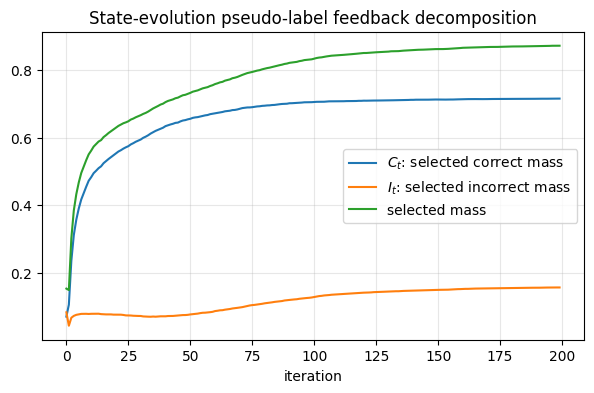

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(se_update["correct_mass"], label=r"$C_t$: selected correct mass")
ax.plot(se_update["incorrect_mass"], label=r"$I_t$: selected incorrect mass")
ax.plot(se_update["omega"] * (1 - run.data_cfg.supervision_ratio), label=r"selected mass")
ax.set(xlabel="iteration", title="State-evolution pseudo-label feedback decomposition")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## $p = 0.2$, $\kappa = \mathrm{logit}(0.95)$

In [27]:
SEED = 2026
T, D, DELTA = 200, 5_000, 4.0
SIGMA, RHO, P, S_MU = 1.0, 0.1, 0.2, 1.0
K_W, K_G = 7_000, 8_500

cfg = make_algorithm_config(
    T=T, eta=0.5, penalty=0.1, pi=2.0, kappa=logit(0.95), include_bias=True
)
run = run_experiment(
    name="representative self-training dynamics", d=D, delta=DELTA, n_test=5_000,
    label_prior=P, rho=RHO, sigma=SIGMA, signal_std=S_MU,
    algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
)
finite_state, se_state = finite_state_observables(run), state_evolution_state_observables(run)
finite_update, se_update = finite_update_observables(run), state_evolution_update_observables(run)

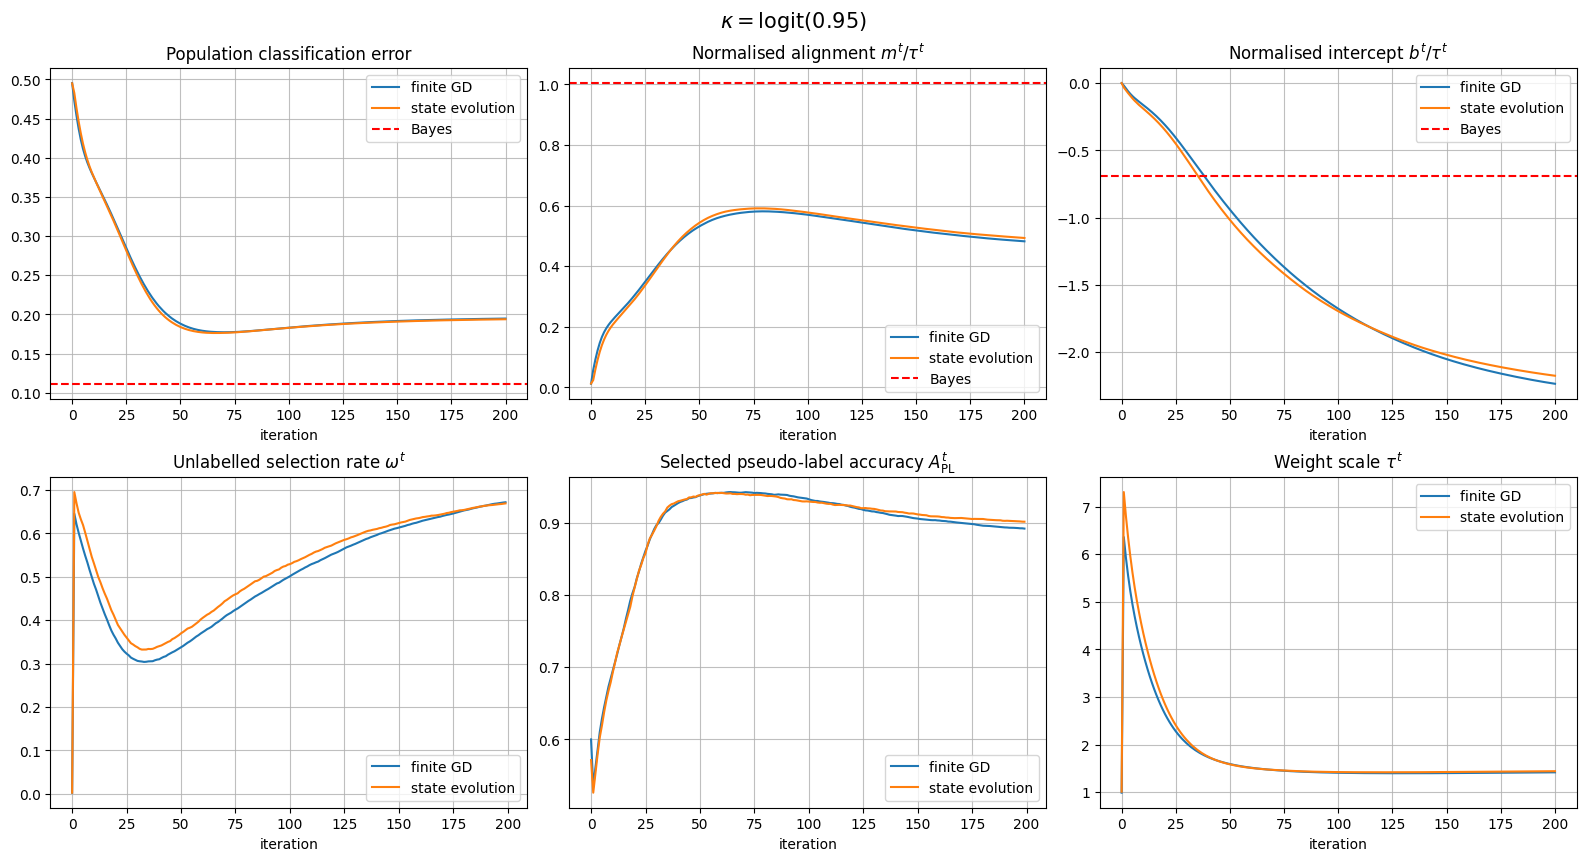

(<Figure size 1575x850 with 6 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Unlabelled selection rate $\\omega^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Selected pseudo-label accuracy $A_{\\rm PL}^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [28]:
plot_macroscopic_evolution(
    run,
    quantities=("error", "normalized_alignment", "normalized_bias", "omega", "accuracy", "tau"),
    sources=("finite", "state_evolution"),
    include_bayes=True,
    title=rf"$\kappa = \mathrm{{logit}}({expit(cfg.margin_threshold):.2f})$",
    nrows=2, ncols=3
)

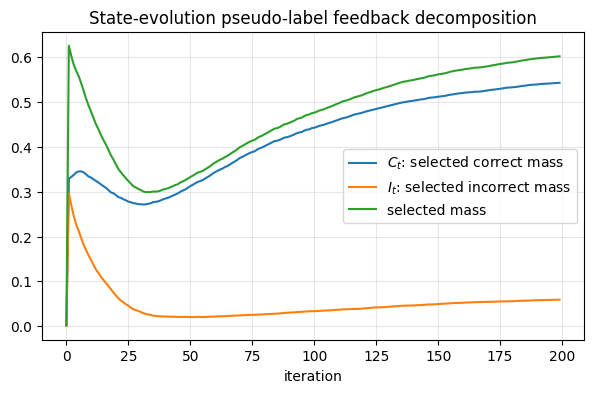

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(se_update["correct_mass"], label=r"$C_t$: selected correct mass")
ax.plot(se_update["incorrect_mass"], label=r"$I_t$: selected incorrect mass")
ax.plot(se_update["omega"] * (1 - run.data_cfg.supervision_ratio), label=r"selected mass")
ax.set(xlabel="iteration", title="State-evolution pseudo-label feedback decomposition")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## Dynamic-outcome and class-conditional diagnostics

Terminal error alone does not distinguish sustained improvement from transient signal recovery followed by instability.  The following diagnostics report the best error, its time index, late-time variation, and a transparent (non-theorem) intercept-dominance flag.  Class-conditional quantities distinguish low coverage from poor pseudo-label precision.

finite {'terminal_error': 0.19468305388540685, 'minimum_error': 0.17721753545347735, 'best_iteration': 70, 'late_error_range': 0.00035179200121421283, 'terminal_normalized_bias': -2.236172522886359, 'terminal_normalized_alignment': 0.4821035304413596, 'terminal_weight_scale': 1.4200411621668636, 'collapsed': False}
state_evolution {'terminal_error': 0.19380802628087035, 'minimum_error': 0.17623685518127938, 'best_iteration': 66, 'late_error_range': 0.00035471036598613837, 'terminal_normalized_bias': -2.1765066089411893, 'terminal_normalized_alignment': 0.4930978759079965, 'terminal_weight_scale': 1.4436270338864607, 'collapsed': False}


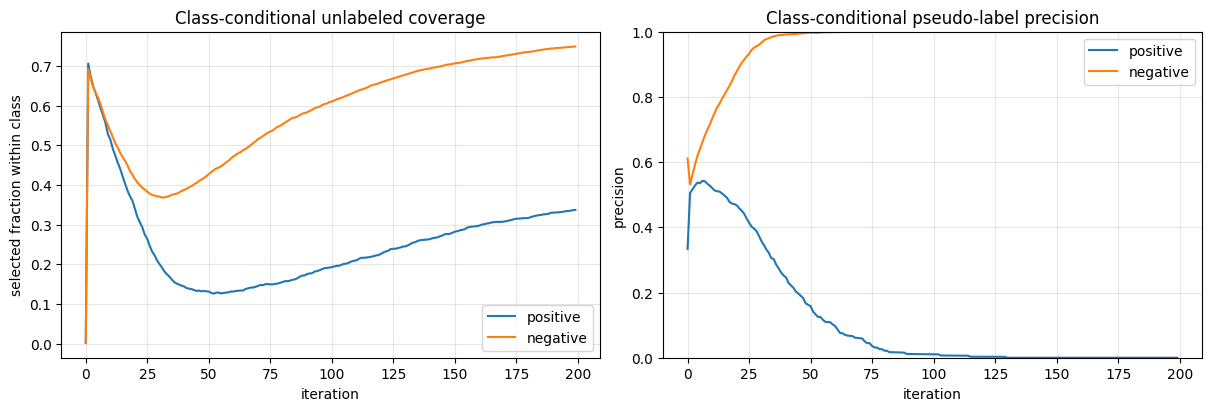

In [30]:
for source in ("finite", "state_evolution"):
    print(source, trajectory_diagnostics(run, source=source))

conditional = class_conditional_update_observables(run, source="state_evolution")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for label, values in conditional.items():
    axes[0].plot(values["coverage"], label=label)
    axes[1].plot(values["precision"], label=label)
axes[0].set(title="Class-conditional unlabeled coverage", xlabel="iteration", ylabel="selected fraction within class")
axes[1].set(title="Class-conditional pseudo-label precision", xlabel="iteration", ylabel="precision", ylim=(0, 1))
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.show()